<a href="https://www.kaggle.com/code/lalit7881/amazon-bestsellers-price-vs-rating-analysis?scriptVersionId=306067521" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/obaidhere/amazon-bestsellers-price-vs-user-rating-analysis/bestsellers with categories.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/obaidhere/amazon-bestsellers-price-vs-user-rating-analysis/bestsellers with categories.csv")

In [3]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [4]:
df.tail()

,Name,Author,User Rating,Reviews,Price,Year,Genre
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction
549,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2019,Non Fiction


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [6]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [7]:
df.isnull().sum()

Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Name            object
Author          object
User Rating    float64
Reviews          int64
Price            int64
Year             int64
Genre           object
dtype: object

In [10]:
df.shape

(550, 7)

In [11]:
df.columns

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')

In [12]:
df.nunique()

Name           351
Author         248
User Rating     14
Reviews        346
Price           40
Year            11
Genre            2
dtype: int64

## EDA

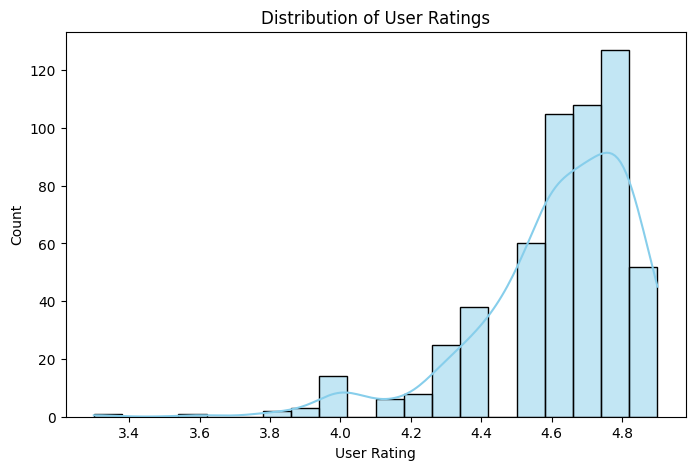

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['User Rating'], bins=20, color='skyblue', kde=True)
plt.title("Distribution of User Ratings")
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.show()

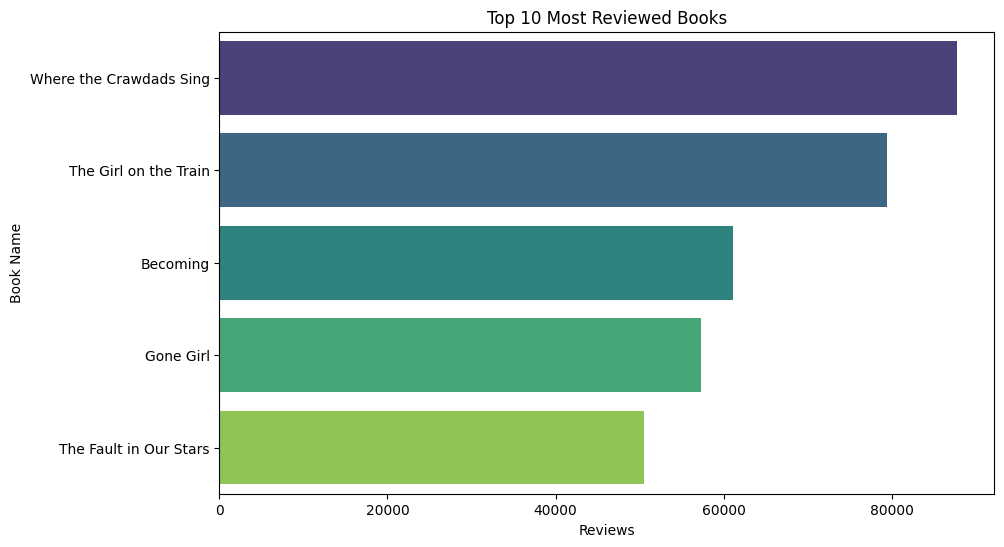

In [14]:
top_reviews = df.sort_values(by='Reviews', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Reviews', y='Name', data=top_reviews, palette='viridis')
plt.title("Top 10 Most Reviewed Books")
plt.xlabel("Reviews")
plt.ylabel("Book Name")
plt.show()

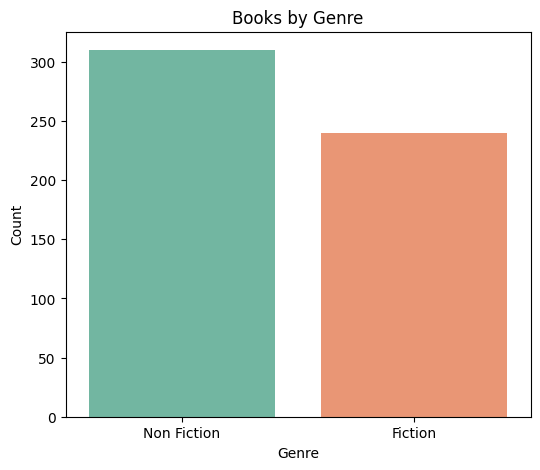

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(x='Genre', data=df, palette='Set2')
plt.title("Books by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

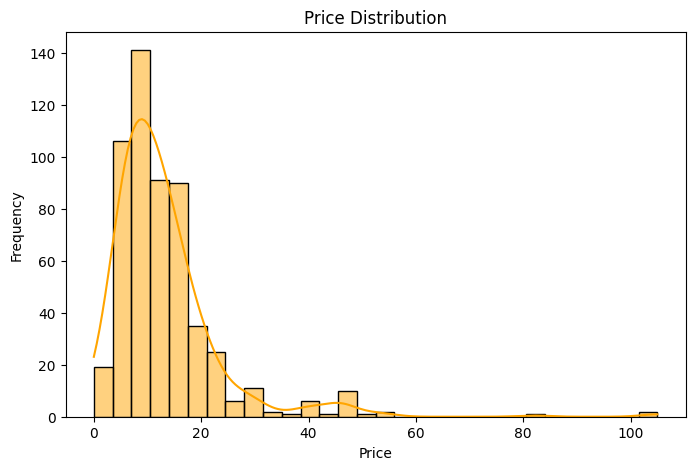

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, color='orange', kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

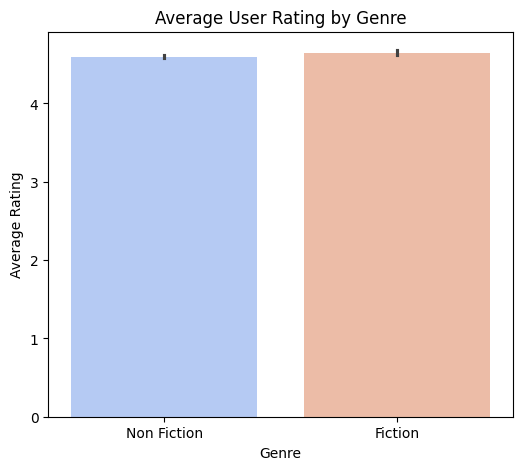

In [17]:
plt.figure(figsize=(6,5))
sns.barplot(x='Genre', y='User Rating', data=df, palette='coolwarm')
plt.title("Average User Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()

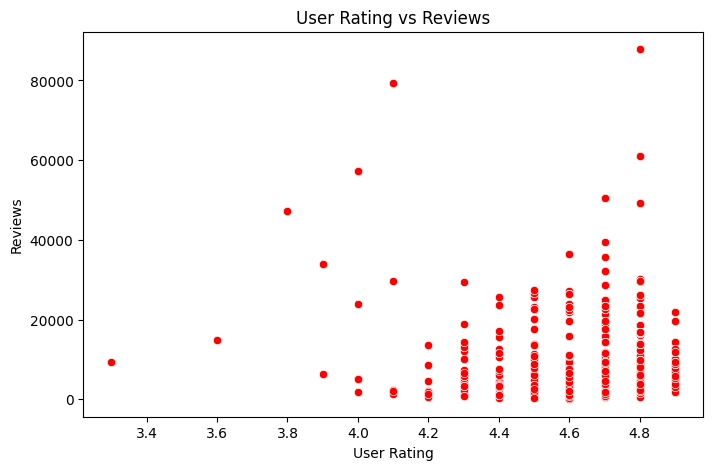

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='User Rating', y='Reviews', data=df, color='red')
plt.title("User Rating vs Reviews")
plt.xlabel("User Rating")
plt.ylabel("Reviews")
plt.show()

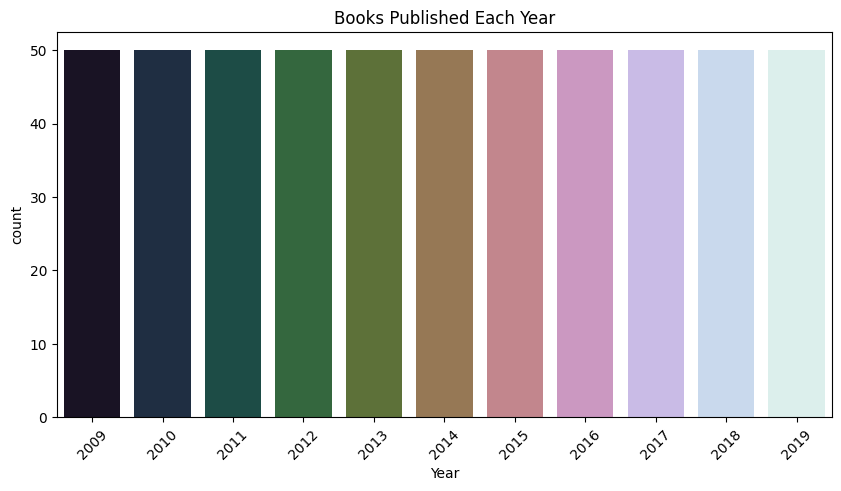

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x='Year', data=df, palette='cubehelix')
plt.title("Books Published Each Year")
plt.xticks(rotation=45)
plt.show()


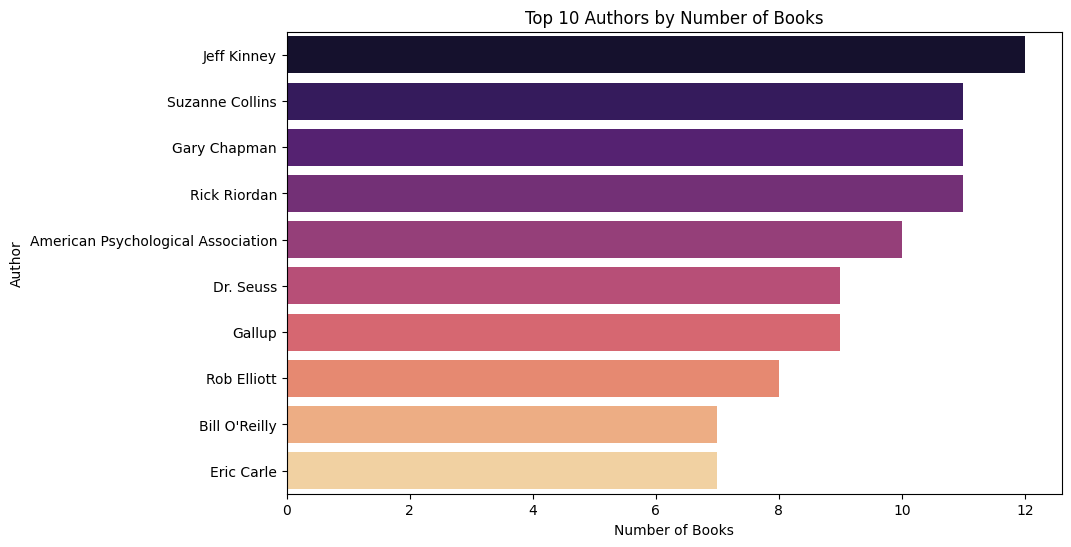

In [20]:
top_authors = df['Author'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='magma')
plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.show()

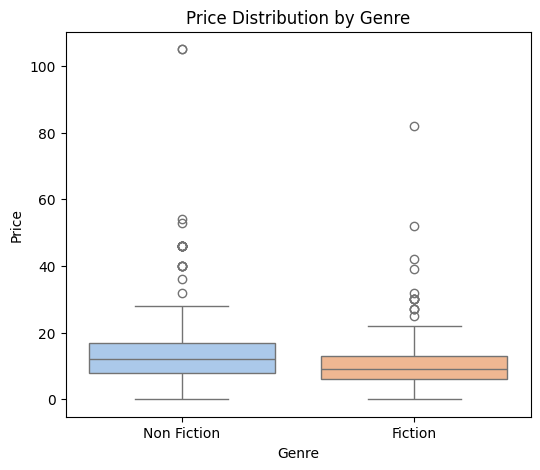

In [21]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Genre', y='Price', data=df, palette='pastel')
plt.title("Price Distribution by Genre")
plt.show()

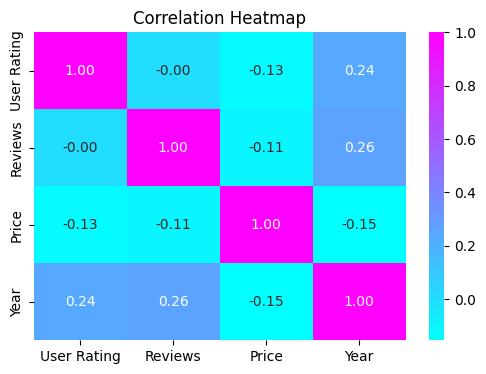

In [22]:
plt.figure(figsize=(6,4))
corr = df[['User Rating', 'Reviews', 'Price', 'Year']].corr()
sns.heatmap(corr, annot=True, cmap='cool', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Feature engineering

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



Logistic Regression Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00       109

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110


Decision Tree Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00       109

    accuracy                           1.00       110
   macro avg       1.00      1.00      1.00       110
weighted avg       1.00      1.00      1.00       110


Random Forest Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00       109

    accurac

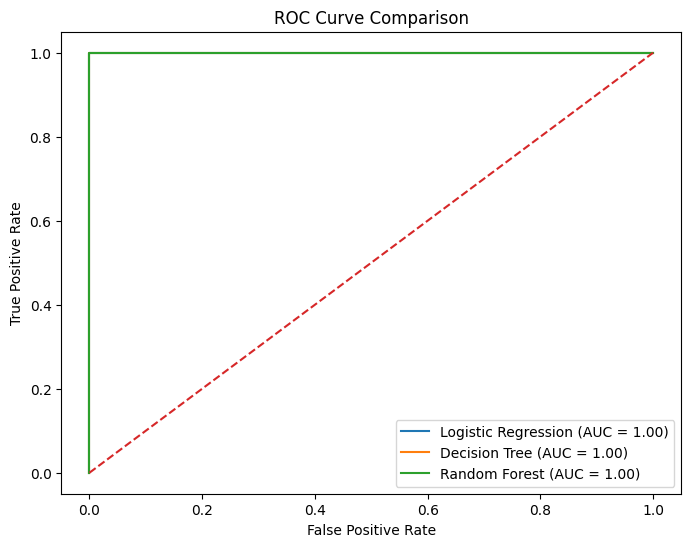


Model Accuracy Comparison:
Logistic Regression: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000


In [24]:
df['Target'] = (df['User Rating'] >= 4.0).astype(int)


# ==============================
df = df.drop(columns=['Name'])  # high cardinality


# ==============================
X = df.drop(columns=['Target'])
y = df['Target']


# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
categorical_cols = ['Author', 'Genre']
numeric_cols = ['User Rating', 'Reviews', 'Price', 'Year']


# ==============================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


# ==============================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}


# ==============================
results = {}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # Create pipeline (NO LEAKAGE)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    results[name] = acc

    # ==============================
    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        y_probs = pipeline.predict_proba(X_test)[:,1]
        
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC Curve
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==============================
print("\nModel Accuracy Comparison:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

## Thank you...pls upvote!!!!!!!!!!
